# SUPPORT VECTOR MACHINE

## Dataset Selection:
For this assignment, we'll utilize the widely recognized Mushroom Dataset

### Task 1: Exploratory Data Analysis (EDA)
1.	Load the Mushroom dataset and perform fundamental data exploration.
2.	Utilize histograms, box plots, or density plots to understand feature distributions.
3.	Investigate feature correlations to discern relationships within the data.

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [5]:
df=pd.read_csv("F:\DATA SCIENCE_ExcelR\Assignments\SVM\mushroom.csv")
df

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,863,sunken,scaly,brown,yes,foul,attached,crowded,narrow,chocolate,...,partial,orange,one,flaring,purple,abundant,leaves,poisonous,5.877891,17.464145
1996,1160,sunken,scaly,purple,yes,musty,attached,distant,narrow,red,...,partial,white,one,zone,yellow,numerous,waste,poisonous,6.500840,13.501957
1997,265,convex,grooves,green,yes,fishy,notched,close,narrow,pink,...,partial,brown,two,evanescent,yellow,abundant,woods,poisonous,13.558064,11.270020
1998,411,bell,smooth,white,no,pungent,free,close,narrow,orange,...,universal,yellow,one,cobwebby,brown,solitary,woods,poisonous,11.092703,8.423199


In [6]:
df.shape

(2000, 26)

In [7]:
df.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [8]:
df.tail()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
1995,863,sunken,scaly,brown,yes,foul,attached,crowded,narrow,chocolate,...,partial,orange,one,flaring,purple,abundant,leaves,poisonous,5.877891,17.464145
1996,1160,sunken,scaly,purple,yes,musty,attached,distant,narrow,red,...,partial,white,one,zone,yellow,numerous,waste,poisonous,6.500840,13.501957
1997,265,convex,grooves,green,yes,fishy,notched,close,narrow,pink,...,partial,brown,two,evanescent,yellow,abundant,woods,poisonous,13.558064,11.270020
1998,411,bell,smooth,white,no,pungent,free,close,narrow,orange,...,universal,yellow,one,cobwebby,brown,solitary,woods,poisonous,11.092703,8.423199
1999,1073,convex,scaly,yellow,yes,pungent,descending,close,narrow,purple,...,partial,white,two,large,white,numerous,urban,poisonous,13.066414,21.056642


In [9]:
df.duplicated().sum()

1024

In [10]:
df=df.drop_duplicates()
print(f"shape after removing duplicates: {df.shape}")

shape after removing duplicates: (976, 26)


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 976 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                976 non-null    int64  
 1   cap_shape                 976 non-null    object 
 2   cap_surface               976 non-null    object 
 3   cap_color                 976 non-null    object 
 4   bruises                   976 non-null    object 
 5   odor                      976 non-null    object 
 6   gill_attachment           976 non-null    object 
 7   gill_spacing              976 non-null    object 
 8   gill_size                 976 non-null    object 
 9   gill_color                976 non-null    object 
 10  stalk_shape               976 non-null    object 
 11  stalk_root                976 non-null    object 
 12  stalk_surface_above_ring  976 non-null    object 
 13  stalk_surface_below_ring  976 non-null    object 
 14  stalk_color_ab

In [12]:
df.isnull().sum()

Unnamed: 0                  0
cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
class                       0
stalk_height                0
cap_diameter                0
dtype: int64

In [13]:
df["class"].value_counts()

class
poisonous    618
edible       358
Name: count, dtype: int64

In [14]:
df.dtypes

Unnamed: 0                    int64
cap_shape                    object
cap_surface                  object
cap_color                    object
bruises                      object
odor                         object
gill_attachment              object
gill_spacing                 object
gill_size                    object
gill_color                   object
stalk_shape                  object
stalk_root                   object
stalk_surface_above_ring     object
stalk_surface_below_ring     object
stalk_color_above_ring       object
stalk_color_below_ring       object
veil_type                    object
veil_color                   object
ring_number                  object
ring_type                    object
spore_print_color            object
population                   object
habitat                      object
class                        object
stalk_height                float64
cap_diameter                float64
dtype: object

In [15]:
df.nunique()

Unnamed: 0                  976
cap_shape                     5
cap_surface                   4
cap_color                     9
bruises                       2
odor                          9
gill_attachment               4
gill_spacing                  3
gill_size                     2
gill_color                   12
stalk_shape                   2
stalk_root                    7
stalk_surface_above_ring      4
stalk_surface_below_ring      4
stalk_color_above_ring        9
stalk_color_below_ring        9
veil_type                     2
veil_color                    4
ring_number                   3
ring_type                     8
spore_print_color             9
population                    6
habitat                       7
class                         2
stalk_height                973
cap_diameter                976
dtype: int64

In [16]:
df=df.drop(columns=['Unnamed: 0'])

In [17]:
df.columns

Index(['cap_shape', 'cap_surface', 'cap_color', 'bruises', 'odor',
       'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color',
       'stalk_shape', 'stalk_root', 'stalk_surface_above_ring',
       'stalk_surface_below_ring', 'stalk_color_above_ring',
       'stalk_color_below_ring', 'veil_type', 'veil_color', 'ring_number',
       'ring_type', 'spore_print_color', 'population', 'habitat', 'class',
       'stalk_height', 'cap_diameter'],
      dtype='object')

In [18]:
df.describe()

,stalk_height,cap_diameter
count,976.000000,976.000000
mean,8.524684,12.598566
std,3.703043,6.987077
min,2.000000,1.000000
25%,5.326820,6.141161
50%,8.367245,12.626094
75%,11.758624,18.559780
max,15.095066,25.000054


In [19]:
categorical_columns=df.drop(columns=["stalk_height","cap_diameter"])

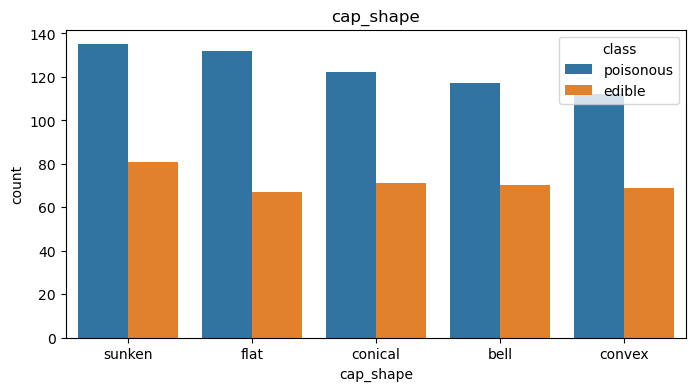

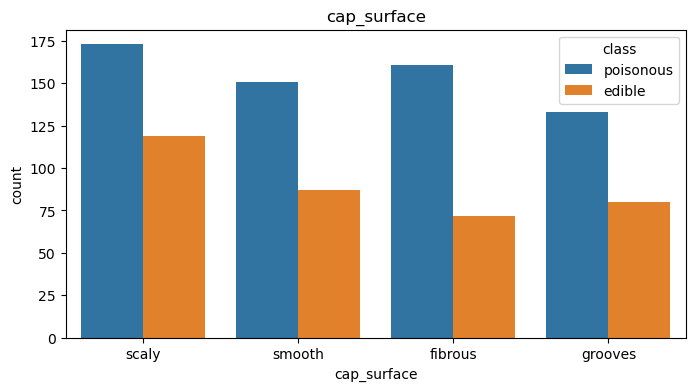

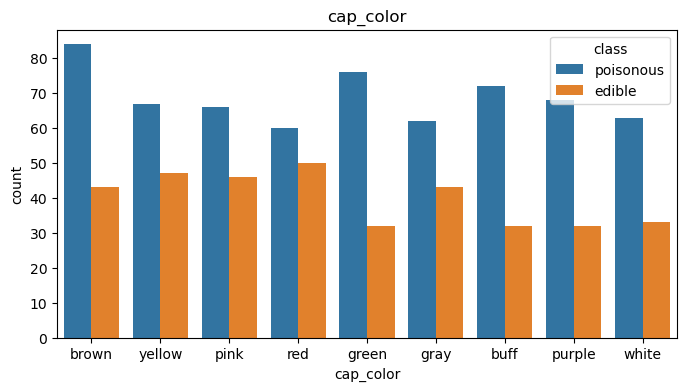

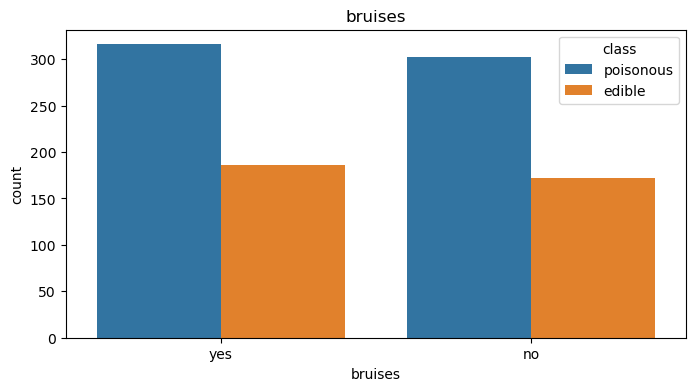

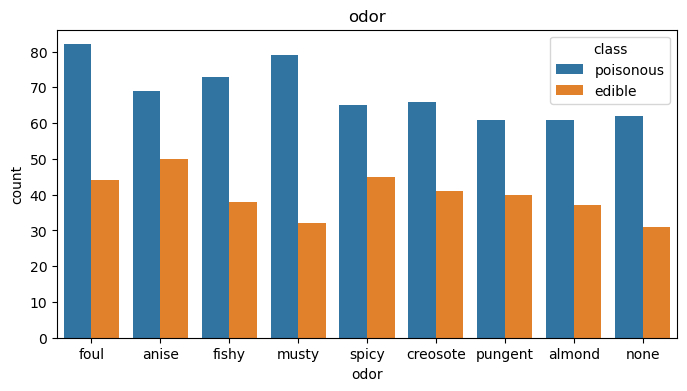

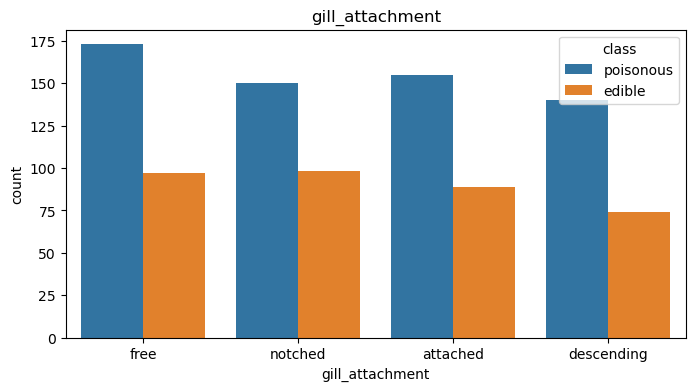

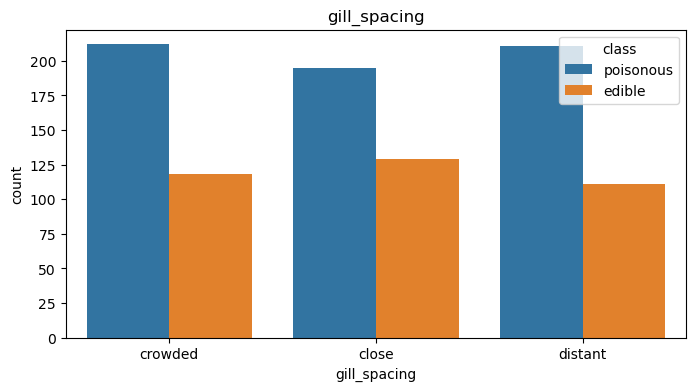

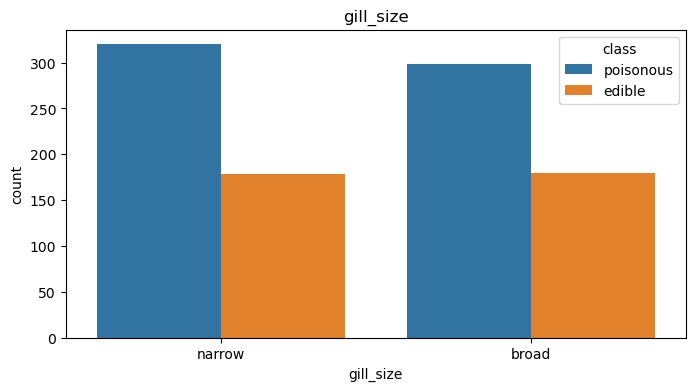

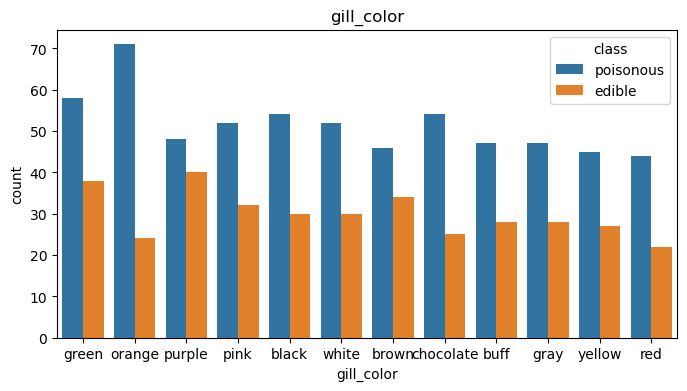

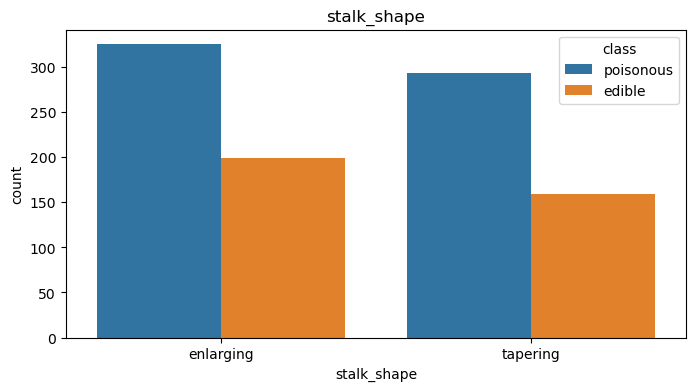

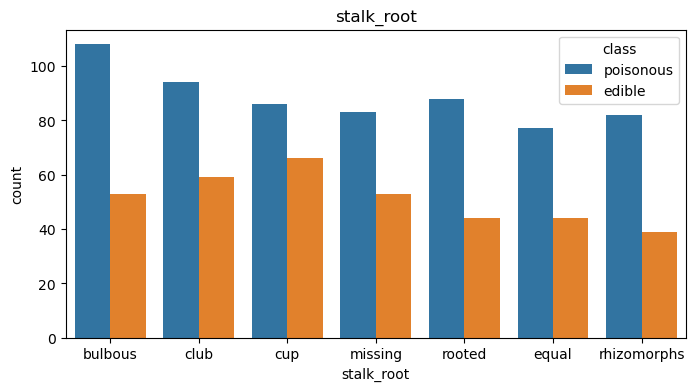

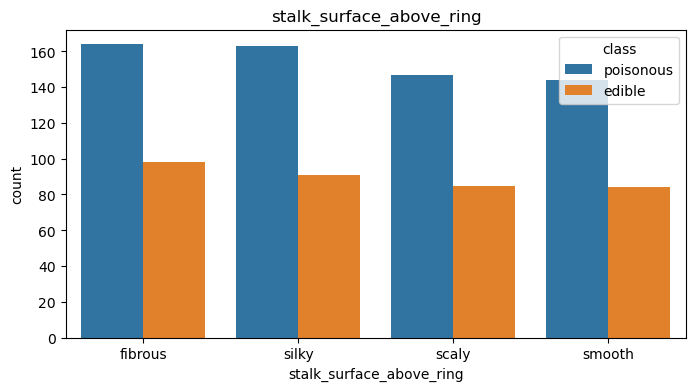

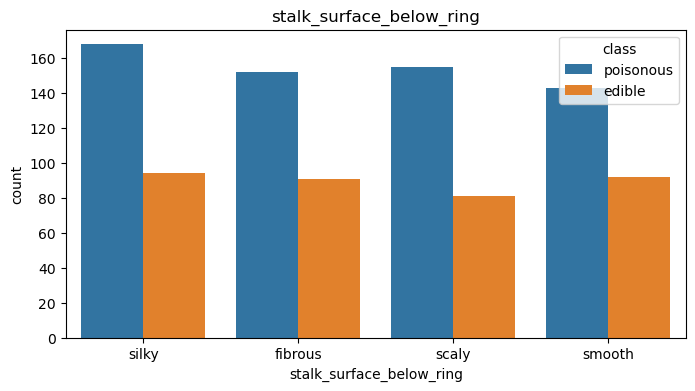

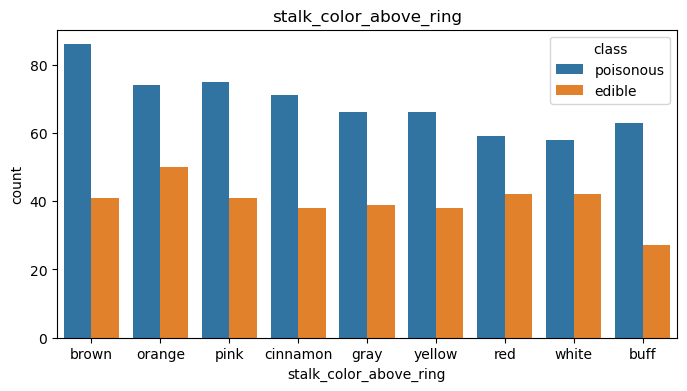

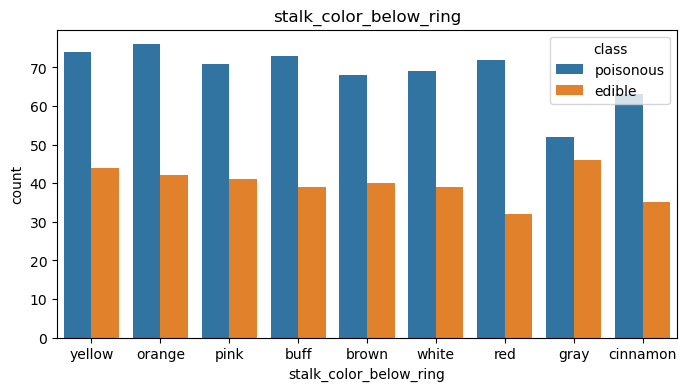

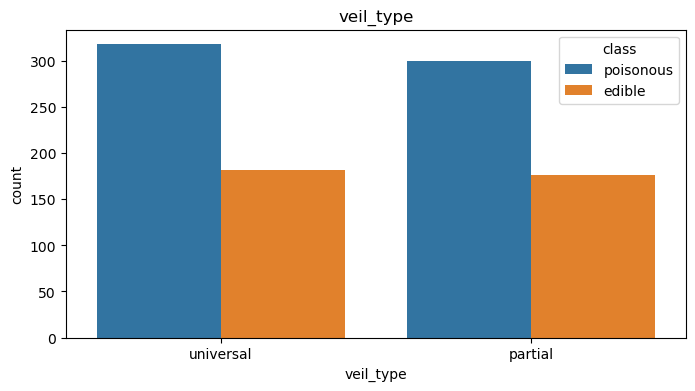

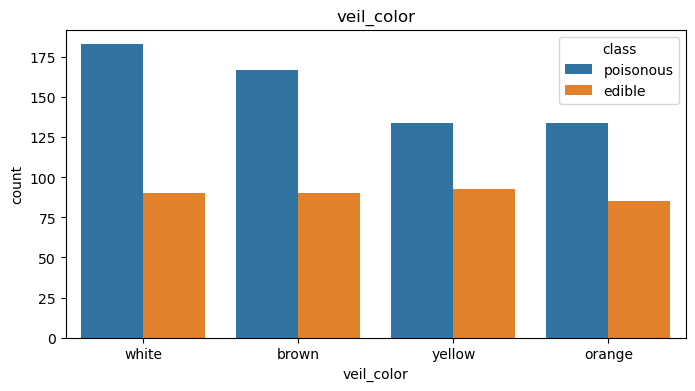

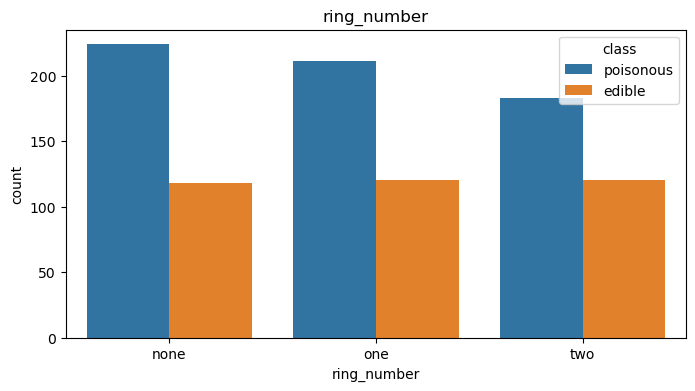

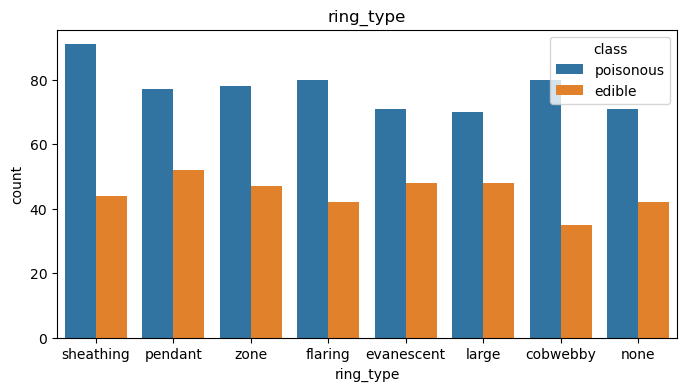

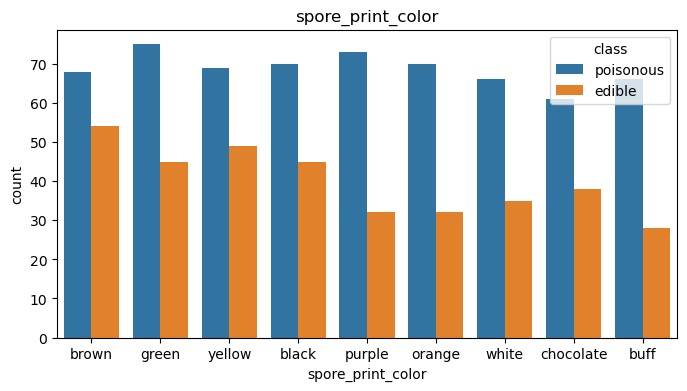

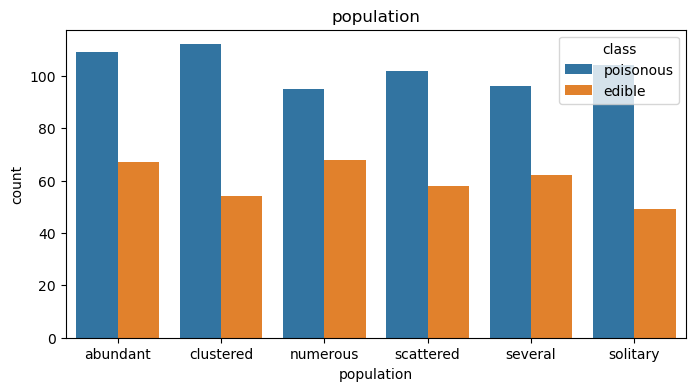

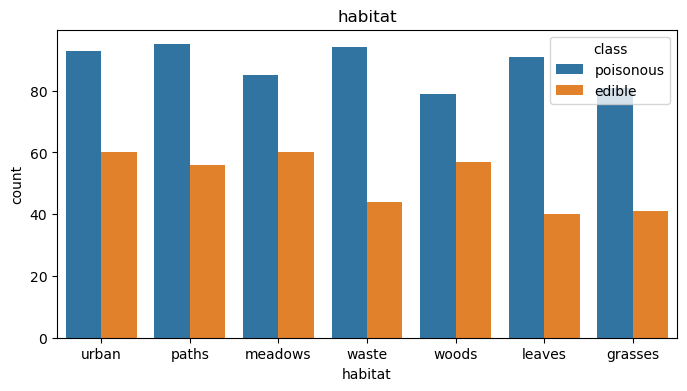

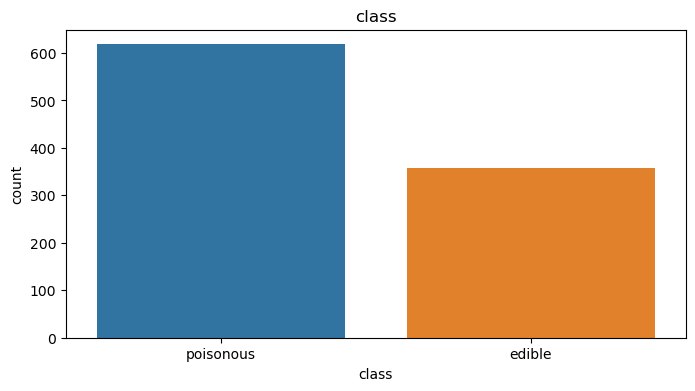

In [20]:
for col in categorical_columns:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col,data=df,order=df[col].value_counts().index,hue='class')
    plt.xlabel(col)
    plt.ylabel('count')
    plt.title(f"{col}")
    plt.show()

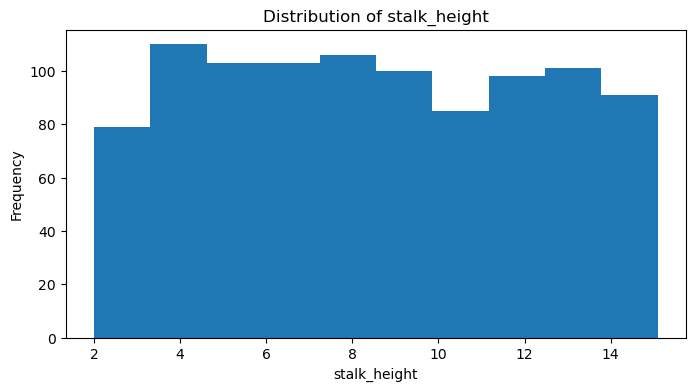

skewness of stalk_height is 0.04532634534862736


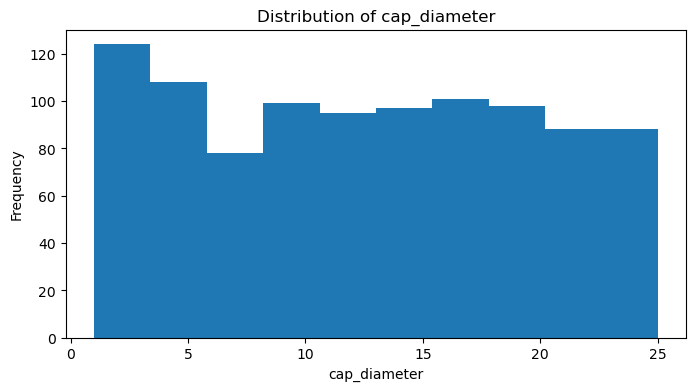

skewness of cap_diameter is 0.029897708226878247


In [21]:
numeric_columns = ["stalk_height", "cap_diameter"]

for col in numeric_columns:
    plt.figure(figsize=(8,4))
    plt.hist(df[col])#, bins=20, color='skyblue', edgecolor='black')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.show()
    print(f"skewness of {col} is {df[col].skew()}")


columm :  stalk_height
No of outliers :  0
Outlier percentage :  0.0





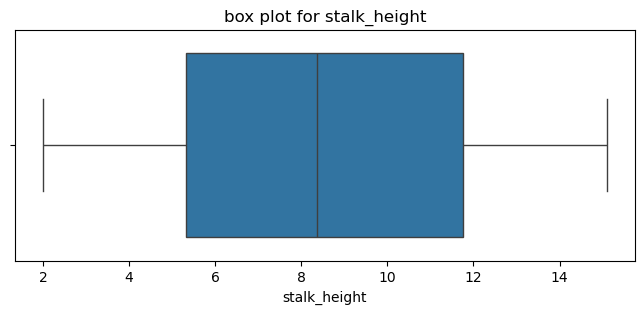

columm :  cap_diameter
No of outliers :  0
Outlier percentage :  0.0





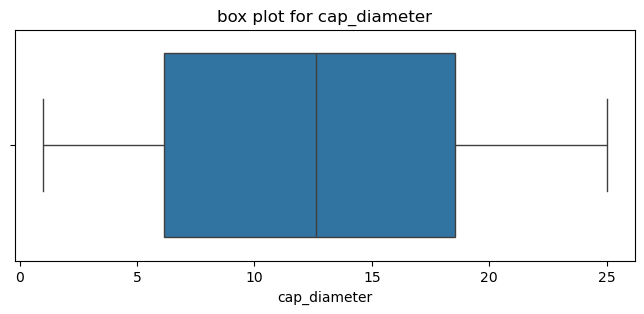

In [37]:
for col in numeric_columns:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    uwl = q3 + 1.5 * iqr
    lwl = q1 - 1.5 * iqr
    outliers = s[(s < lwl) | (s > uwl)]
    print("columm : ",col)
    print("No of outliers : ",len(outliers))
    percent=(len(outliers)/len(df))*100
    print("Outlier percentage : ",np.round(percent,3))
    print("\n\n")
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(f"box plot for {col}")
    plt.xlabel(col)
    plt.show()


### Task 2: Data Preprocessing
1.	Encode categorical variables if necessary.
2.	Split the dataset into training and testing sets.

### Task 3: Data Visualization
1.	Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.
2.	Visualize class distributions to gauge dataset balance or imbalance.


In [43]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])  # edible=0, poisonous=1
df['class'].head()

0    1
1    0
2    1
3    1
4    1
Name: class, dtype: int32

In [44]:
categorical_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=categorical_cols)
df.head()

,class,stalk_height,cap_diameter,cap_shape_bell,cap_shape_conical,cap_shape_convex,cap_shape_flat,cap_shape_sunken,cap_surface_fibrous,cap_surface_grooves,...,population_scattered,population_several,population_solitary,habitat_grasses,habitat_leaves,habitat_meadows,habitat_paths,habitat_urban,habitat_waste,habitat_woods
0,1,14.276173,5.054983,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
1,0,3.952715,19.068319,False,False,False,False,True,True,False,...,False,False,False,False,False,False,False,False,True,False
2,1,9.054265,7.205884,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,True,False
3,1,5.226499,20.932692,True,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,1,14.037532,12.545245,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [45]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['stalk_height','cap_diameter']] = scaler.fit_transform(df[['stalk_height','cap_diameter']])

In [46]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [47]:
df.head()

,class,stalk_height,cap_diameter,cap_shape_bell,cap_shape_conical,cap_shape_convex,cap_shape_flat,cap_shape_sunken,cap_surface_fibrous,cap_surface_grooves,...,population_scattered,population_several,population_solitary,habitat_grasses,habitat_leaves,habitat_meadows,habitat_paths,habitat_urban,habitat_waste,habitat_woods
0,1,1.553976,-1.080201,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,-1.235285,0.926435,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,1,0
2,1,0.143086,-0.772204,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
3,1,-0.891126,1.193403,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,1,1.489498,-0.007635,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0


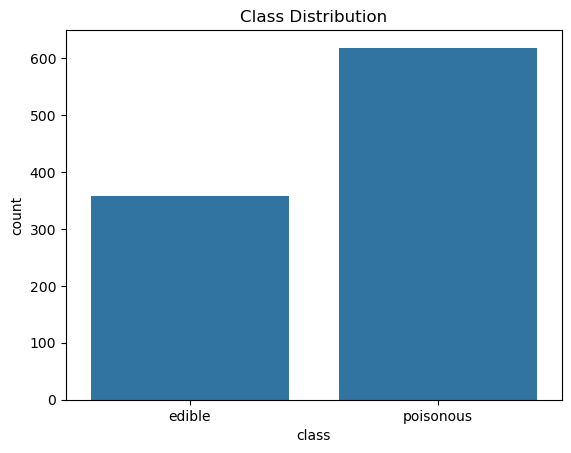

In [48]:
sns.countplot(x='class', data=df)
plt.xticks([0,1], ['edible','poisonous'])
plt.title("Class Distribution")
plt.show()

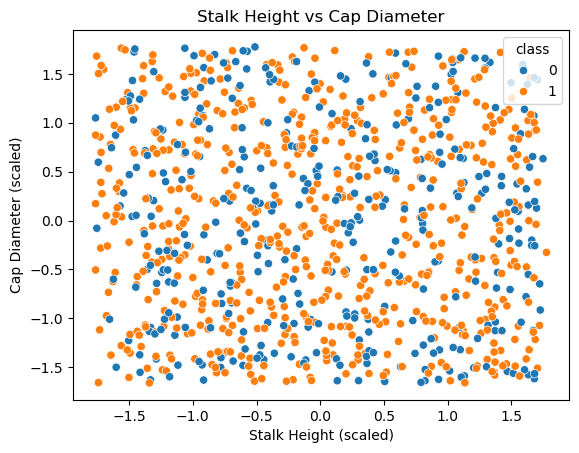

In [49]:
sns.scatterplot(x='stalk_height', y='cap_diameter', hue='class', data=df)
plt.xlabel("Stalk Height (scaled)")
plt.ylabel("Cap Diameter (scaled)")
plt.title("Stalk Height vs Cap Diameter")
plt.show()

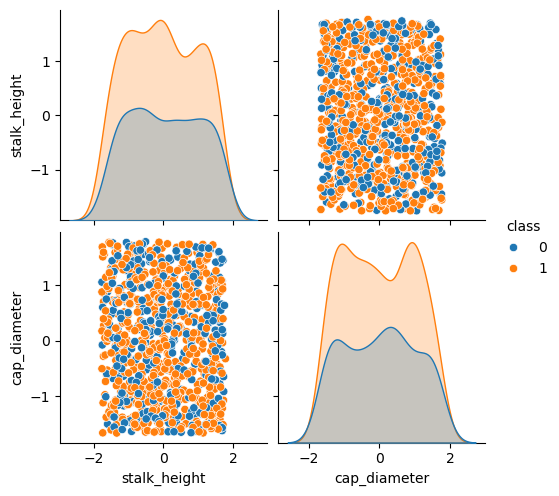

In [50]:
sns.pairplot(df, vars=['stalk_height','cap_diameter'], hue='class')
plt.show()

In [52]:
numeric_cols = ['stalk_height', 'cap_diameter', 'class']
corr=df[numeric_cols].corr()
corr

,stalk_height,cap_diameter,class
stalk_height,1.000000,-0.034891,-0.038474
cap_diameter,-0.034891,1.000000,-0.007975
class,-0.038474,-0.007975,1.000000


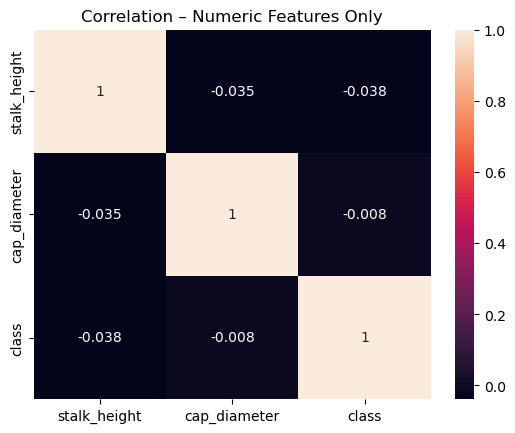

In [54]:

sns.heatmap(corr, annot=True)
plt.title("Correlation – Numeric Features Only")
plt.show()


In [56]:
X=df.drop(columns=['class'])
Y=df['class']

In [63]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=14,stratify=Y)

In [67]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (780, 126)
X_test shape: (196, 126)
Y_train shape: (780,)
Y_test shape: (196,)


### Task 4: SVM Implementation
1.	Implement a basic SVM classifier using Python libraries like scikit-learn.
2.	Train the SVM model on the training data.
3.	Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).

In [73]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [75]:
svm = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm.fit(X_train, Y_train)

SVC(class_weight='balanced', random_state=42)

In [77]:
Y_train_pred = svm.predict(X_train)
Y_test_pred = svm.predict(X_test)

In [79]:
test_accuracy=accuracy_score(Y_test, Y_test_pred)
train_accuracy=accuracy_score(Y_train,Y_train_pred)
report=classification_report(Y_test, Y_test_pred)
cm=confusion_matrix(Y_test, Y_test_pred)

In [81]:
print("Train Accuracy:", np.round(train_accuracy, 4))
print("Test Accuracy:", np.round(test_accuracy, 4))
print("\nClassification Report:\n", report)
print("Confusion Matrix:\n", cm)

Train Accuracy: 0.9333
Test Accuracy: 0.551

Classification Report:
               precision    recall  f1-score   support

           0       0.41      0.50      0.45        72
           1       0.67      0.58      0.62       124

    accuracy                           0.55       196
   macro avg       0.54      0.54      0.54       196
weighted avg       0.57      0.55      0.56       196

Confusion Matrix:
 [[36 36]
 [52 72]]


### Task 5: Visualization of SVM Results
1.	Visualize classification results on the testing data.

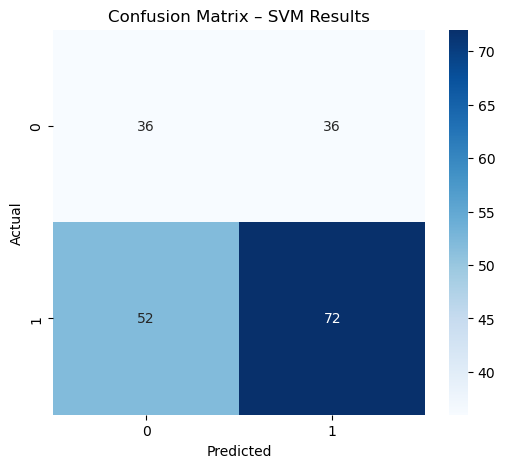

In [85]:
cm = confusion_matrix(Y_test, Y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – SVM Results")
plt.show()

### Task 6: Parameter Tuning and Optimization
Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.

In [93]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.1, 2, 10],
    'gamma': ['scale', 'auto',0.1,0.01]
}

svm = SVC(class_weight='balanced', random_state=42)


In [88]:
clf = SVC()
param_grid = [{'kernel':['rbf','polynomial','radial'],'gamma':[50,5,10,0.5],'C':[15,14,13,12,11,10,0.1,0.001] }]
grid_search = GridSearchCV(clf,param_grid,cv=10)
grid_search.fit(X_train,Y_train)

GridSearchCV(cv=10, estimator=SVC(),
             param_grid=[{'C': [15, 14, 13, 12, 11, 10, 0.1, 0.001],
                          'gamma': [50, 5, 10, 0.5],
                          'kernel': ['rbf', 'polynomial', 'radial']}])

In [90]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'C': 15, 'gamma': 50, 'kernel': 'rbf'}
Best CV Score: 0.6333333333333332


In [92]:
grid_search = GridSearchCV(
    SVC(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=SVC(class_weight='balanced', random_state=42),
             n_jobs=-1,
             param_grid=[{'C': [15, 14, 13, 12, 11, 10, 0.1, 0.001],
                          'gamma': [50, 5, 10, 0.5],
                          'kernel': ['rbf', 'polynomial', 'radial']}],
             scoring='accuracy')

In [94]:
best_svm = grid_search.best_estimator_
Y_train_pred = best_svm.predict(X_train)
Y_test_pred = best_svm.predict(X_test)

In [96]:
test_accuracy=accuracy_score(Y_test, Y_test_pred)
train_accuracy=accuracy_score(Y_train,Y_train_pred)
report=classification_report(Y_test, Y_test_pred)
cm=confusion_matrix(Y_test, Y_test_pred)

In [98]:
print("Train Accuracy:", np.round(train_accuracy, 4))
print("Test Accuracy:", np.round(test_accuracy, 4))
print("\nClassification Report:\n", report)
print("Confusion Matrix:\n", cm)

Train Accuracy: 1.0
Test Accuracy: 0.6327

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        72
           1       0.63      1.00      0.78       124

    accuracy                           0.63       196
   macro avg       0.32      0.50      0.39       196
weighted avg       0.40      0.63      0.49       196

Confusion Matrix:
 [[  0  72]
 [  0 124]]


### Task 7: Comparison and Analysis
1.	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).
2.	Analyze SVM strengths and weaknesses for the Mushroom dataset based on EDA and visualization results.
3.	Discuss practical implications of SVM in real-world classification tasks.

In [103]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

for kernel in kernels:
    print(f"\n----- Kernel: {kernel} -----")
    svm = SVC(kernel=kernel, class_weight='balanced', C=1, gamma='scale', random_state=42)
    svm.fit(X_train, Y_train) 
    
    Y_train_pred = svm.predict(X_train)
    Y_test_pred = svm.predict(X_test)
    
    train_accuracy = accuracy_score(Y_train, Y_train_pred)
    test_accuracy = accuracy_score(Y_test, Y_test_pred)
    report = classification_report(Y_test, Y_test_pred)
    cm = confusion_matrix(Y_test, Y_test_pred)
    
    print("Train Accuracy:", np.round(train_accuracy, 4))
    print("Test Accuracy:", np.round(test_accuracy, 4))
    print("\nClassification Report:\n", report)
    print("Confusion Matrix:\n", cm)



----- Kernel: linear -----
Train Accuracy: 0.6564
Test Accuracy: 0.5408

Classification Report:
               precision    recall  f1-score   support

           0       0.40      0.51      0.45        72
           1       0.66      0.56      0.61       124

    accuracy                           0.54       196
   macro avg       0.53      0.54      0.53       196
weighted avg       0.57      0.54      0.55       196

Confusion Matrix:
 [[37 35]
 [55 69]]

----- Kernel: poly -----
Train Accuracy: 1.0
Test Accuracy: 0.551

Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.21      0.25        72
           1       0.62      0.75      0.68       124

    accuracy                           0.55       196
   macro avg       0.47      0.48      0.47       196
weighted avg       0.51      0.55      0.52       196

Confusion Matrix:
 [[15 57]
 [31 93]]

----- Kernel: rbf -----
Train Accuracy: 0.9333
Test Accuracy: 0.551

Classifica

------------------------------------------------------------
### Compare SVM performance with various kernels:
* Linear kernel achieved moderate accuracy (~54%) – data not linearly separable.
* Polynomial kernel overfitted (Train=100%, Test~55%) – too complex.
* RBF kernel performed best (~55%) but needs parameter tuning (C, gamma).
* Sigmoid kernel performed worst (~45%) – not suitable for this dataset.

### Analyze SVM strengths and weaknesses for the Mushroom dataset:
* Strengths: Handles non-linear boundaries, works well on small/medium datasets,and can manage imbalanced data using class_weight='balanced'.
* Weaknesses: Sensitive to parameter tuning, prone to overfitting, and performance drops on imbalanced or high-dimensional data.

### Discuss practical implications of SVM in real-world classification tasks:
* SVM is effective for non-linear classification problems (e.g., text, bio-data).
* Requires proper preprocessing, feature scaling, and tuning for good performance.
* Best suited for moderate-sized datasets; not ideal for very large ones.
* Kernel flexibility makes SVM adaptable but increases computational cost.
------------------------------------------------------------
